In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# # Download from Zenodo
# !wget https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip

# # Unzip
# !unzip -o weights_pneumoniamnist.zip

# import shutil
# shutil.copy('resnet18_224_1.pth', '/content/drive/MyDrive/resnet_18_weights_folder_iter1/resnet18_224_1.pth')
# print('Weights saved to Google Drive!')

## Use the code below when Google Colab resets

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

path_to_model = '/content/drive/MyDrive/resnet_18_weights_folder_iter1/resnet18_224_1.pth'

model = models.resnet18()
model.fc = torch.nn.Linear(512, 2)

# MedMNIST saves weights under a 'net' key
state_dict = torch.load(path_to_model, map_location=device)
model.load_state_dict(state_dict['net'])

model = model.to(device)
model.eval()
print('Model loaded successfully!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Model loaded successfully!


In [4]:
# confirmation
import os
print(os.path.exists('/content/drive/MyDrive/resnet_18_weights_folder_iter1/resnet18_224_1.pth'))

True


In [5]:
# Install dependencies
!pip install medmnist scikit-learn --quiet

In [6]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score

print('All libraries loaded!')

All libraries loaded!


In [7]:
from medmnist import PneumoniaMNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert 1 channel to 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])  # Now normalize all 3 channels
])

test_dataset = PneumoniaMNIST(split='test', transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f'Test set reloaded: {len(test_dataset)} images')

Test set reloaded: 624 images


In [8]:
# setting up the attack functions
def brightness_attack(images, delta):
    """
    Brightness shift attack.
    Adds delta to every pixel.
    Positive delta = brighter, Negative delta = darker
    """
    perturbed = images + delta
    return torch.clamp(perturbed, -1, 1)


def contrast_attack(images, alpha):
    """
    Contrast shift attack.
    Scales every pixel by alpha.
    alpha > 1 = more contrast, alpha < 1 = less contrast
    """
    perturbed = alpha * images
    return torch.clamp(perturbed, -1, 1)

print('Attack functions defined!')

Attack functions defined!


In [9]:
# evaluation function
def evaluate(model, loader, attack_fn=None, attack_param=None):
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long()

            # Apply attack if specified
            if attack_fn is not None:
                images = attack_fn(images, attack_param)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, all_preds)

    # Now also return labels and preds so we can use them outside
    return auc, acc, all_labels, all_preds

In [10]:
# checking
clean_auc, clean_acc, clean_labels, clean_preds = evaluate(model, test_loader)
print(f'Clean Baseline — AUC: {clean_auc:.4f} | Accuracy: {clean_acc:.4f}')

Clean Baseline — AUC: 0.9490 | Accuracy: 0.8638


In [11]:
# brightness attack

brightness_deltas = [-0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

brightness_aucs = []
brightness_accs = []

for delta in brightness_deltas:
    auc, acc, _, _ = evaluate(model, test_loader, attack_fn=brightness_attack, attack_param=delta)
    brightness_aucs.append(auc)
    brightness_accs.append(acc)
    print(f'Delta={delta:+.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Delta=-0.5 — AUC: 0.9444 | ACC: 0.7997
Delta=-0.4 — AUC: 0.9599 | ACC: 0.8285
Delta=-0.3 — AUC: 0.9636 | ACC: 0.8446
Delta=-0.2 — AUC: 0.9593 | ACC: 0.8510
Delta=-0.1 — AUC: 0.9511 | ACC: 0.8558
Delta=+0.0 — AUC: 0.9490 | ACC: 0.8638
Delta=+0.1 — AUC: 0.9424 | ACC: 0.8558
Delta=+0.2 — AUC: 0.9389 | ACC: 0.8446
Delta=+0.3 — AUC: 0.9352 | ACC: 0.8317
Delta=+0.4 — AUC: 0.9306 | ACC: 0.8173
Delta=+0.5 — AUC: 0.9127 | ACC: 0.7452


In [12]:
# constrast attack

contrast_alphas = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

contrast_aucs = []
contrast_accs = []

for alpha in contrast_alphas:
    auc, acc, _, _ = evaluate(model, test_loader, attack_fn=contrast_attack, attack_param=alpha)
    contrast_aucs.append(auc)
    contrast_accs.append(acc)
    print(f'Alpha={alpha:.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Alpha=0.2 — AUC: 0.5064 | ACC: 0.6250
Alpha=0.4 — AUC: 0.7666 | ACC: 0.6474
Alpha=0.6 — AUC: 0.9102 | ACC: 0.7468
Alpha=0.8 — AUC: 0.9437 | ACC: 0.8269
Alpha=1.0 — AUC: 0.9490 | ACC: 0.8638
Alpha=1.2 — AUC: 0.9469 | ACC: 0.8718
Alpha=1.4 — AUC: 0.9454 | ACC: 0.8654
Alpha=1.6 — AUC: 0.9468 | ACC: 0.8702
Alpha=1.8 — AUC: 0.9468 | ACC: 0.8638
Alpha=2.0 — AUC: 0.9450 | ACC: 0.8654


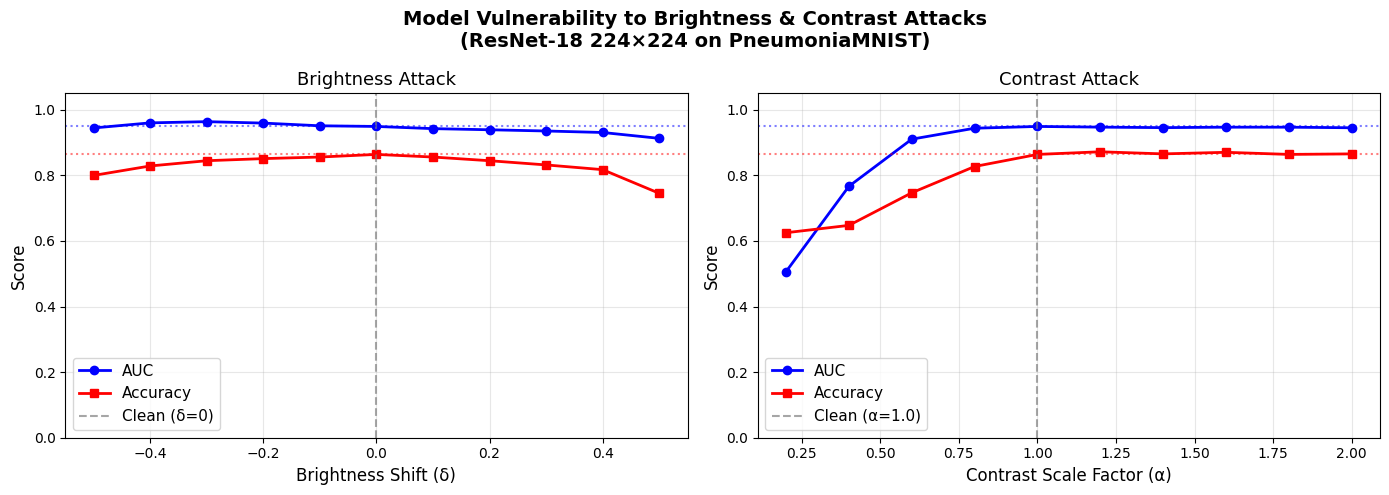

Vulnerability curves saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Vulnerability to Brightness & Contrast Attacks\n(ResNet-18 224×224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

# --- Brightness Plot ---
ax1 = axes[0]
ax1.plot(brightness_deltas, brightness_aucs, 'b-o', label='AUC', linewidth=2)
ax1.plot(brightness_deltas, brightness_accs, 'r-s', label='Accuracy', linewidth=2)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Clean (δ=0)')
ax1.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax1.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Brightness Shift (δ)', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Brightness Attack', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# --- Contrast Plot ---
ax2 = axes[1]
ax2.plot(contrast_alphas, contrast_aucs, 'b-o', label='AUC', linewidth=2)
ax2.plot(contrast_alphas, contrast_accs, 'r-s', label='Accuracy', linewidth=2)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7, label='Clean (α=1.0)')
ax2.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax2.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax2.set_xlabel('Contrast Scale Factor (α)', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Contrast Attack', fontsize=13)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vulnerability_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vulnerability curves saved!')

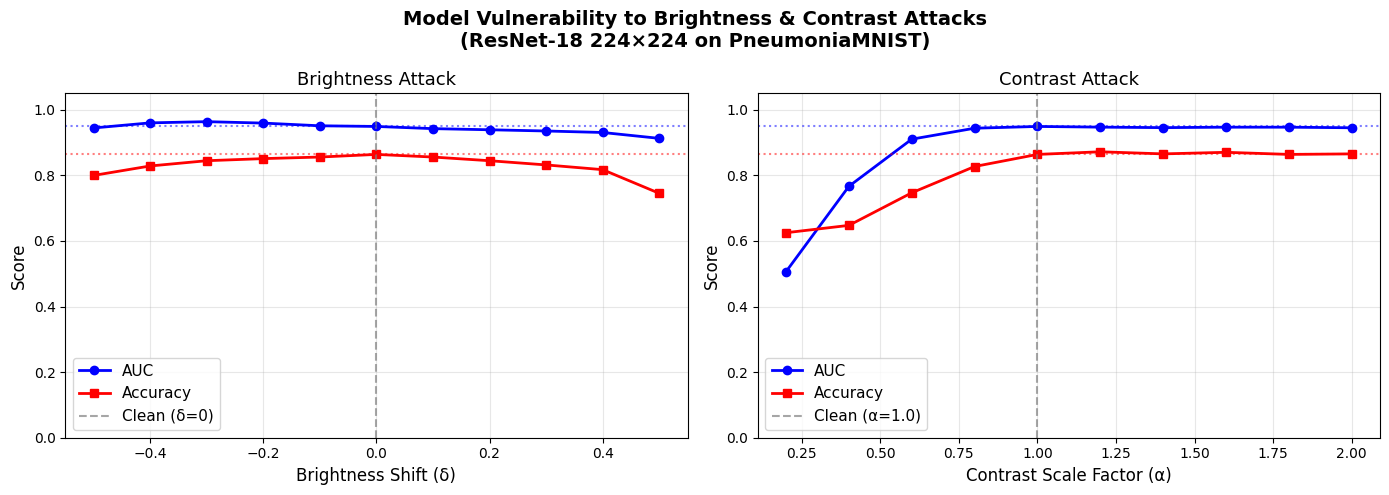

Vulnerability curves saved!


In [14]:
import matplotlib.pyplot as plt

# vulnerability curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Vulnerability to Brightness & Contrast Attacks\n(ResNet-18 224×224 on PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

# Brightness plot
ax1 = axes[0]
ax1.plot(brightness_deltas, brightness_aucs, 'b-o', label='AUC', linewidth=2)
ax1.plot(brightness_deltas, brightness_accs, 'r-s', label='Accuracy', linewidth=2)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Clean (δ=0)')
ax1.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax1.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Brightness Shift (δ)', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Brightness Attack', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Contrast plot
ax2 = axes[1]
ax2.plot(contrast_alphas, contrast_aucs, 'b-o', label='AUC', linewidth=2)
ax2.plot(contrast_alphas, contrast_accs, 'r-s', label='Accuracy', linewidth=2)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7, label='Clean (α=1.0)')
ax2.axhline(y=clean_auc, color='blue', linestyle=':', alpha=0.5)
ax2.axhline(y=clean_acc, color='red', linestyle=':', alpha=0.5)
ax2.set_xlabel('Contrast Scale Factor (α)', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Contrast Attack', fontsize=13)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vulnerability_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Vulnerability curves saved!')

In [15]:
import shutil
shutil.copy('vulnerability_curves.png', '/content/drive/MyDrive/resnet_18_weights_folder_iter1/vulnerability_curves.png')
print('Plot saved to Google Drive!')

Plot saved to Google Drive!


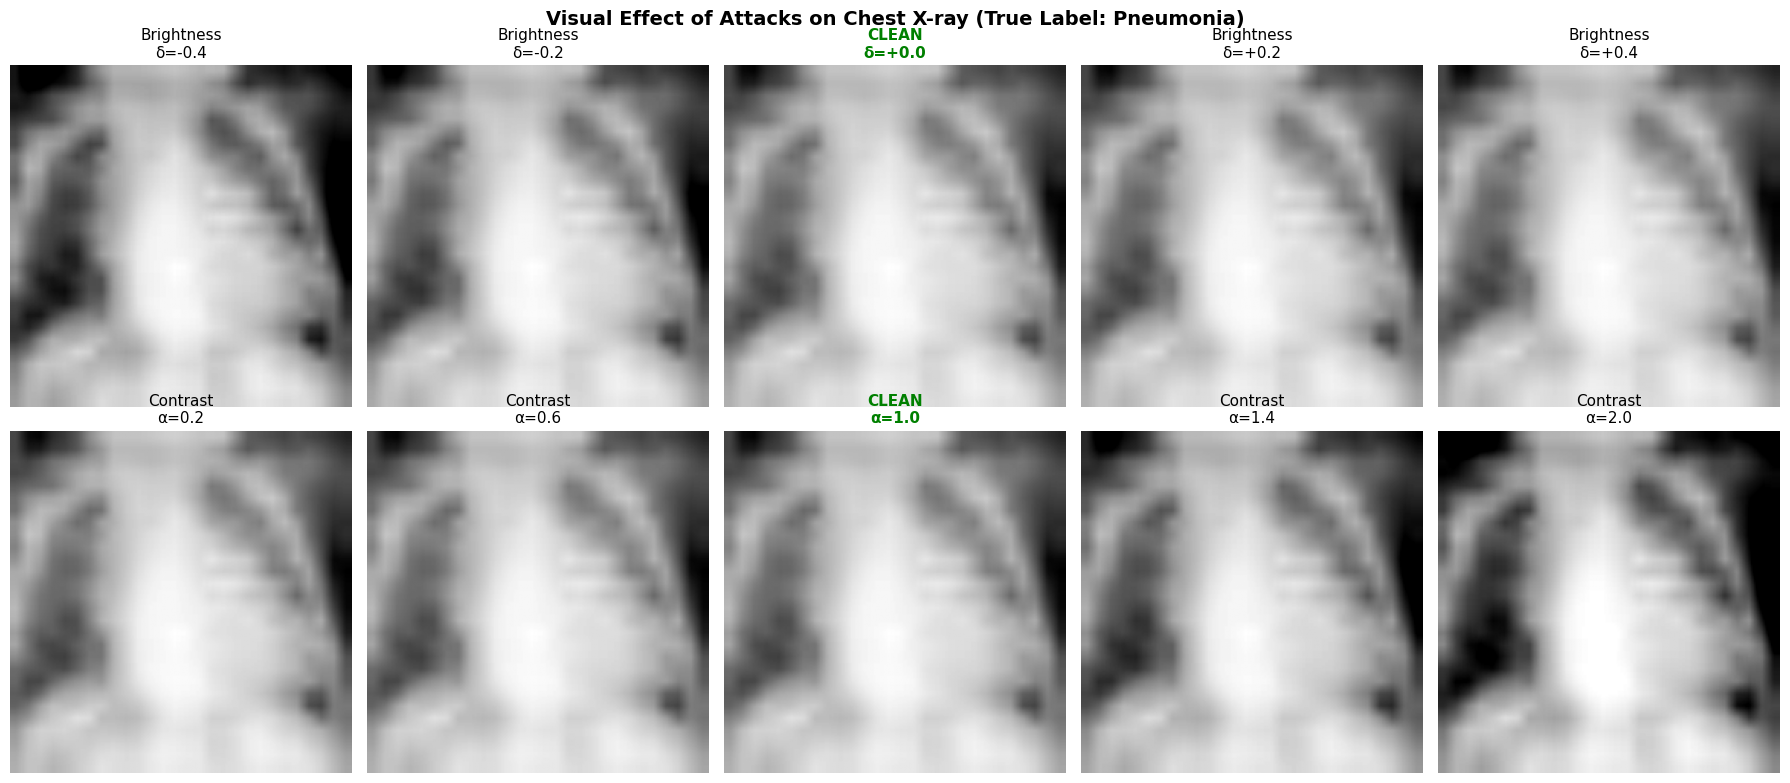

Visualization saved!


In [16]:
import matplotlib.pyplot as plt
import torch

# visualize attack effects on X-rays

def denormalize(tensor):
    """Convert normalized tensor back to [0,1] for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Grab one sample X-ray from the test set
sample_images, sample_labels = next(iter(test_loader))
sample_img = sample_images[0].unsqueeze(0).to(device)
label_text = 'Pneumonia' if sample_labels[0].item() == 1 else 'Normal'

# Levels to visualize
viz_deltas = [-0.4, -0.2, 0.0, 0.2, 0.4]
viz_alphas = [0.2, 0.6, 1.0, 1.4, 2.0]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle(f'Visual Effect of Attacks on Chest X-ray (True Label: {label_text})',
             fontsize=14, fontweight='bold')

# Row 1: Brightness shifts
for i, delta in enumerate(viz_deltas):
    perturbed = brightness_attack(sample_img, delta)
    img_display = denormalize(perturbed.squeeze().cpu())[0]  # Take first channel
    axes[0, i].imshow(img_display, cmap='gray')
    if delta == 0.0:
        axes[0, i].set_title(f'CLEAN\nδ={delta:+.1f}', fontsize=11, color='green', fontweight='bold')
    else:
        axes[0, i].set_title(f'Brightness\nδ={delta:+.1f}', fontsize=11)
    axes[0, i].axis('off')

# Row 2: Contrast shifts
for i, alpha in enumerate(viz_alphas):
    perturbed = contrast_attack(sample_img, alpha)
    img_display = denormalize(perturbed.squeeze().cpu())[0]  # Take first channel
    axes[1, i].imshow(img_display, cmap='gray')
    if alpha == 1.0:
        axes[1, i].set_title(f'CLEAN\nα={alpha:.1f}', fontsize=11, color='green', fontweight='bold')
    else:
        axes[1, i].set_title(f'Contrast\nα={alpha:.1f}', fontsize=11)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('attack_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved!')

In [17]:
# Get a batch of images and labels from the test set
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.squeeze().long()

In [18]:
# which specific images fail first under attack
for delta in brightness_deltas:
    auc, acc, _, _ = evaluate(model, test_loader, attack_fn=brightness_attack, attack_param=delta)
    brightness_aucs.append(auc)
    brightness_accs.append(acc)
    print(f'Delta={delta:+.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Delta=-0.5 — AUC: 0.9444 | ACC: 0.7997
Delta=-0.4 — AUC: 0.9599 | ACC: 0.8285
Delta=-0.3 — AUC: 0.9636 | ACC: 0.8446
Delta=-0.2 — AUC: 0.9593 | ACC: 0.8510
Delta=-0.1 — AUC: 0.9511 | ACC: 0.8558
Delta=+0.0 — AUC: 0.9490 | ACC: 0.8638
Delta=+0.1 — AUC: 0.9424 | ACC: 0.8558
Delta=+0.2 — AUC: 0.9389 | ACC: 0.8446
Delta=+0.3 — AUC: 0.9352 | ACC: 0.8317
Delta=+0.4 — AUC: 0.9306 | ACC: 0.8173
Delta=+0.5 — AUC: 0.9127 | ACC: 0.7452


In [19]:
# does brightness shift cause more pneumonia cases (false negatives) or more false alarms (false positives)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(clean_labels, clean_preds)
print('Clean Baseline Confusion Matrix:')
print(f'True Negatives:  {cm[0,0]}')
print(f'False Positives: {cm[0,1]}')
print(f'False Negatives: {cm[1,0]}')
print(f'True Positives:  {cm[1,1]}')

Clean Baseline Confusion Matrix:
True Negatives:  151
False Positives: 83
False Negatives: 2
True Positives:  388


In [20]:
# what happens when I apply both the brightness and constrast attack simultaneously
def combined_attack(images, params):
    delta, alpha = params  # Unpack the tuple
    perturbed = alpha * images + delta
    return torch.clamp(perturbed, -1, 1)

# Test worst case combination
auc, acc, _, _ = evaluate(model, test_loader,
                    attack_fn=combined_attack,
                    attack_param=(0.3, 0.4))
print(f'Combined attack (delta=0.3, alpha=0.4) — AUC: {auc:.4f} | ACC: {acc:.4f}')

Combined attack (delta=0.3, alpha=0.4) — AUC: 0.7411 | ACC: 0.6314


In [21]:
# How confident is the model in its wrong predictions under attack?
perturbed = contrast_attack(images, alpha=0.2)
outputs = model(perturbed)
probs = torch.softmax(outputs, dim=1)
max_confidence = probs.max(dim=1).values
print(f'Average confidence under attack: {max_confidence.mean():.4f}')

Average confidence under attack: 1.0000


In [22]:
# Confusion matrix under worst case contrast attack (δ=+0.5 for brightness, α=0.2 for contrast)
auc, acc, attack_labels, attack_preds = evaluate(
    model, test_loader,
    attack_fn=contrast_attack,
    attack_param=0.2
)

cm_attack = confusion_matrix(attack_labels, attack_preds)
print('Contrast Attack (α=0.2) Confusion Matrix:')
print(f'True Negatives:  {cm_attack[0,0]}')
print(f'False Positives: {cm_attack[0,1]}')
print(f'False Negatives: {cm_attack[1,0]}')
print(f'True Positives:  {cm_attack[1,1]}')

Contrast Attack (α=0.2) Confusion Matrix:
True Negatives:  0
False Positives: 234
False Negatives: 0
True Positives:  390


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# precision and recall under attack
precision = precision_score(attack_labels, attack_preds)
recall = recall_score(attack_labels, attack_preds)
f1 = f1_score(attack_labels, attack_preds)
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

Precision: 0.6250
Recall:    1.0000
F1 Score:  0.7692


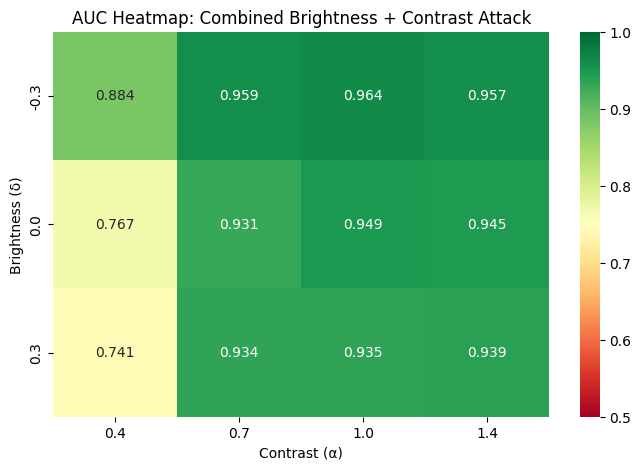

In [24]:
# testing a grid of delta and alpha values together and visualize as a heatmap
import numpy as np
import seaborn as sns

deltas = [-0.3, 0.0, 0.3]
alphas = [0.4, 0.7, 1.0, 1.4]

results = np.zeros((len(deltas), len(alphas)))

for i, delta in enumerate(deltas):
    for j, alpha in enumerate(alphas):
        auc, acc, _, _ = evaluate(model, test_loader,
                                   attack_fn=combined_attack,
                                   attack_param=(delta, alpha))
        results[i, j] = auc

plt.figure(figsize=(8, 5))
sns.heatmap(results,
            xticklabels=alphas,
            yticklabels=deltas,
            annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.5, vmax=1.0)
plt.xlabel('Contrast (α)')
plt.ylabel('Brightness (δ)')
plt.title('AUC Heatmap: Combined Brightness + Contrast Attack')
plt.savefig('combined_attack_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# histogram equalization
import cv2
import numpy as np

def histogram_equalization(images):
    """Apply CLAHE preprocessing as a defense against contrast attacks."""
    # Convert tensor to numpy, apply CLAHE, convert back
    defended = []
    for img in images.cpu().numpy():
        img_uint8 = ((img[0] + 1) * 127.5).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        equalized = clahe.apply(img_uint8)
        equalized = (equalized / 127.5 - 1.0).astype(np.float32)
        defended.append(torch.tensor(equalized).unsqueeze(0).repeat(3, 1, 1))
    return torch.stack(defended).to(images.device)

## Gamma Correction attacks

In [26]:
def gamma_attack(images, gamma):
    """
    Gamma correction attack.
    gamma < 1 = brightens dark areas (overexposed look)
    gamma > 1 = darkens bright areas (underexposed look)
    """
    # Convert from [-1,1] to [0,1] for gamma correction
    images_01 = (images + 1) / 2
    perturbed = torch.pow(images_01.clamp(min=1e-8), gamma)
    # Convert back to [-1,1]
    return (perturbed * 2 - 1).clamp(-1, 1)

print('Gamma attack defined!')

Gamma attack defined!


In [27]:
gammas = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]

gamma_aucs = []
gamma_accs = []

for gamma in gammas:
    auc, acc, _, _ = evaluate(model, test_loader,
                               attack_fn=gamma_attack,
                               attack_param=gamma)
    gamma_aucs.append(auc)
    gamma_accs.append(acc)
    print(f'Gamma={gamma:.1f} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Gamma=0.1 — AUC: 0.5000 | ACC: 0.6250
Gamma=0.3 — AUC: 0.6813 | ACC: 0.6266
Gamma=0.5 — AUC: 0.9208 | ACC: 0.7500
Gamma=0.7 — AUC: 0.9348 | ACC: 0.8285
Gamma=1.0 — AUC: 0.9490 | ACC: 0.8638
Gamma=1.5 — AUC: 0.9615 | ACC: 0.8654
Gamma=2.0 — AUC: 0.9446 | ACC: 0.8141
Gamma=3.0 — AUC: 0.8761 | ACC: 0.6779
Gamma=5.0 — AUC: 0.6672 | ACC: 0.6266


In [28]:
def local_brightness_attack(images, delta, region='center'):
    """
    Applies brightness shift only to a specific region of the image.
    Mimics a localized scanner artifact.
    """
    perturbed = images.clone()
    _, _, H, W = images.shape

    if region == 'center':
        # Attack the center region where lungs typically are
        h_start, h_end = H//4, 3*H//4
        w_start, w_end = W//4, 3*W//4
    elif region == 'left':
        h_start, h_end = 0, H
        w_start, w_end = 0, W//2
    elif region == 'right':
        h_start, h_end = 0, H
        w_start, w_end = W//2, W

    perturbed[:, :, h_start:h_end, w_start:w_end] += delta
    return torch.clamp(perturbed, -1, 1)

print('Local brightness attack defined!')

Local brightness attack defined!


In [29]:
# compare regional attacks

regions = ['center', 'left', 'right']

for region in regions:
    def regional_attack(images, delta, r=region):
        return local_brightness_attack(images, delta, region=r)

    auc, acc, _, _ = evaluate(model, test_loader,
                               attack_fn=regional_attack,
                               attack_param=0.4)
    print(f'Region={region:8s} — AUC: {auc:.4f} | ACC: {acc:.4f}')

Region=center   — AUC: 0.8834 | ACC: 0.6394
Region=left     — AUC: 0.9378 | ACC: 0.8333
Region=right    — AUC: 0.9220 | ACC: 0.7276


In [30]:
#stretch only the high or low end of the contrast range
def contrast_stretch_attack(images, params):
    """
    Clips pixel values at low and high percentiles then rescales.
    Simulates overexposure or underexposure of specific tonal ranges.
    """
    low_clip, high_clip = params  # Unpack the tuple
    perturbed = images.clone()
    perturbed = torch.clamp(perturbed, low_clip, high_clip)
    # Rescale back to [-1, 1]
    perturbed = (perturbed - low_clip) / (high_clip - low_clip) * 2 - 1
    return perturbed

print('Contrast stretching defined!')

Contrast stretching defined!


In [31]:
auc, acc, _, _ = evaluate(model, test_loader,
                           attack_fn=contrast_stretch_attack,
                           attack_param=(-0.5, 0.5))
print(f'Contrast stretch [-0.5, 0.5] — AUC: {auc:.4f} | ACC: {acc:.4f}')

Contrast stretch [-0.5, 0.5] — AUC: 0.9450 | ACC: 0.8654


In [32]:
clip_ranges = [(-0.8, 0.8), (-0.5, 0.5), (-0.3, 0.3), (-0.1, 0.1)]

for low, high in clip_ranges:
    auc, acc, _, _ = evaluate(model, test_loader,
                               attack_fn=contrast_stretch_attack,
                               attack_param=(low, high))
    print(f'Clip [{low:.1f}, {high:.1f}] — AUC: {auc:.4f} | ACC: {acc:.4f}')

Clip [-0.8, 0.8] — AUC: 0.9463 | ACC: 0.8686
Clip [-0.5, 0.5] — AUC: 0.9450 | ACC: 0.8654
Clip [-0.3, 0.3] — AUC: 0.9296 | ACC: 0.8301
Clip [-0.1, 0.1] — AUC: 0.8902 | ACC: 0.7724


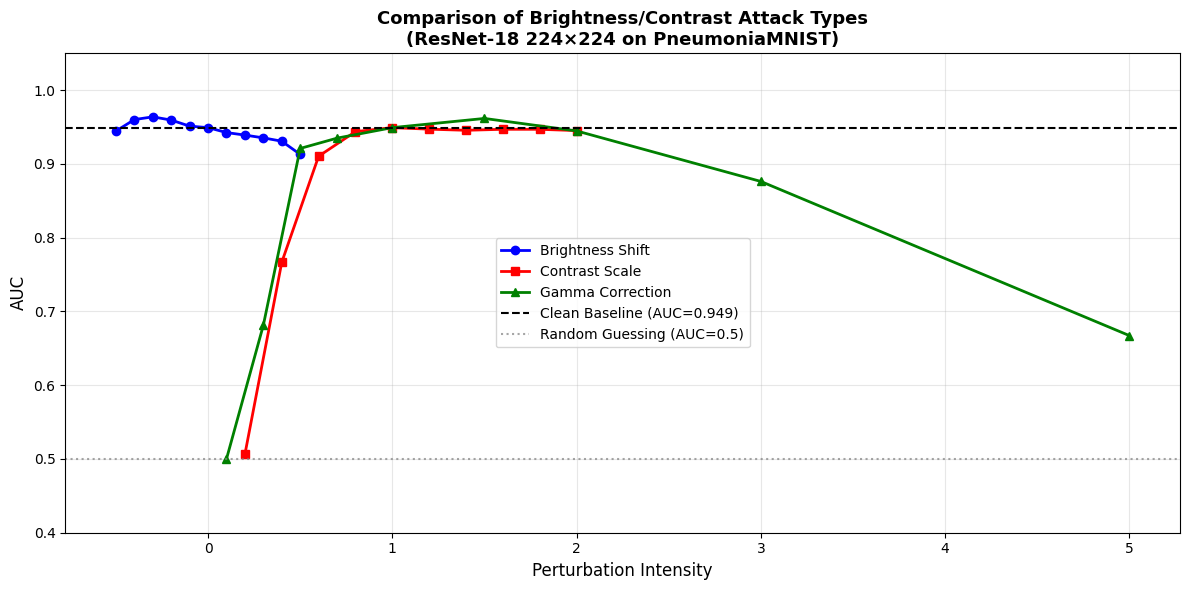

In [33]:
# comparing all attacks

# Ensure brightness_aucs and brightness_accs have the correct length
# This is a defensive measure in case the attack evaluation cells are run multiple times
brightness_aucs = brightness_aucs[:len(brightness_deltas)]
brightness_accs = brightness_accs[:len(brightness_deltas)]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(brightness_deltas, brightness_aucs, 'b-o', label='Brightness Shift', linewidth=2)
ax.plot(contrast_alphas, contrast_aucs, 'r-s', label='Contrast Scale', linewidth=2)
ax.plot(gammas, gamma_aucs, 'g-^', label='Gamma Correction', linewidth=2)
ax.axhline(y=clean_auc, color='black', linestyle='--', label=f'Clean Baseline (AUC={clean_auc:.3f})')
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.7, label='Random Guessing (AUC=0.5)')

ax.set_xlabel('Perturbation Intensity', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Comparison of Brightness/Contrast Attack Types\n(ResNet-18 224\u00d7224 on PneumoniaMNIST)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.savefig('attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# simple robustness summary

print('=' * 60)
print('MODEL ROBUSTNESS SUMMARY')
print('=' * 60)

print(f'\nClean Baseline AUC: {clean_auc:.4f}')
print()

# Brightness robustness
worst_brightness_auc = min(brightness_aucs)
worst_brightness_delta = brightness_deltas[brightness_aucs.index(worst_brightness_auc)]
print(f'Brightness Attack:')
print(f'  Worst AUC: {worst_brightness_auc:.4f} at δ={worst_brightness_delta:+.1f}')
print(f'  AUC Drop:  {clean_auc - worst_brightness_auc:.4f}')
print(f'  Verdict:   {"ROBUST" if clean_auc - worst_brightness_auc < 0.05 else "VULNERABLE"}')

print()

# Contrast robustness
worst_contrast_auc = min(contrast_aucs)
worst_contrast_alpha = contrast_alphas[contrast_aucs.index(worst_contrast_auc)]
print(f'Contrast Attack:')
print(f'  Worst AUC: {worst_contrast_auc:.4f} at α={worst_contrast_alpha:.1f}')
print(f'  AUC Drop:  {clean_auc - worst_contrast_auc:.4f}')
print(f'  Verdict:   {"ROBUST" if clean_auc - worst_contrast_auc < 0.05 else "VULNERABLE"}')

print()

# Gamma robustness
worst_gamma_auc = min(gamma_aucs)
worst_gamma = gammas[gamma_aucs.index(worst_gamma_auc)]
print(f'Gamma Attack:')
print(f'  Worst AUC: {worst_gamma_auc:.4f} at γ={worst_gamma:.1f}')
print(f'  AUC Drop:  {clean_auc - worst_gamma_auc:.4f}')
print(f'  Verdict:   {"ROBUST" if clean_auc - worst_gamma_auc < 0.05 else "VULNERABLE"}')
print()
print('=' * 60)

MODEL ROBUSTNESS SUMMARY

Clean Baseline AUC: 0.9490

Brightness Attack:
  Worst AUC: 0.9127 at δ=+0.5
  AUC Drop:  0.0363
  Verdict:   ROBUST

Contrast Attack:
  Worst AUC: 0.5064 at α=0.2
  AUC Drop:  0.4426
  Verdict:   VULNERABLE

Gamma Attack:
  Worst AUC: 0.5000 at γ=0.1
  AUC Drop:  0.4490
  Verdict:   VULNERABLE

